# 🧱 Step-by-Step 01: Build a Mini GPT-OSS From Scratch (on your Mac)

**Goal:** build a small language model that has the *same skeleton* as OpenAI's open-weight **GPT-OSS** models (gpt-oss-20b and gpt-oss-120b), train it on this laptop in a few minutes, and watch it write text.

**Who this is for:** anyone who is curious. No maths background needed. Every piece is explained in plain language first, then in code. If you only read the plain-language parts, you will still understand how GPT-OSS works.

---

## What is a language model, in one sentence?

> A language model is a machine that reads some text and **guesses what comes next**, one small piece at a time.

That is the whole game. "Write me a poem" is answered by guessing the next piece, adding it to the text, guessing again, and repeating hundreds of times. Everything in this notebook exists to make that one guess good.

## What makes GPT-OSS special?

GPT-OSS (released by OpenAI in August 2025, Apache 2.0 licence) is a **Mixture-of-Experts Transformer**. Compared with the classic Transformer from *Attention Is All You Need*, it has five modern twists. We will build every one of them:

| Ingredient | Plain-language meaning | Real gpt-oss-20b | Our mini version |
|---|---|---|---|
| Tokens | The "alphabet" the model reads and writes | 201,088-piece dictionary (`o200k_harmony`) | ~65 single characters |
| RMSNorm | A volume knob that keeps numbers sane | ✅ | ✅ |
| RoPE | A way of stamping each word with *where* it sits | ✅ (extended to 128k words with YaRN) | ✅ (plain RoPE) |
| Grouped-Query Attention | Each word looks around the sentence; several "askers" share one "answer book" to save memory | 64 query heads, 8 key/value heads | 4 query heads, 2 key/value heads |
| Attention sinks | A permanent "listen to nobody" option in each head | ✅ | ✅ |
| Sliding-window attention | Every second floor only looks at the nearest 128 words | window = 128, alternating layers | window = 32, alternating layers |
| Mixture of Experts (MoE) | A receptionist sends each word to the 4 most relevant specialists out of 32 | 32 experts, top-4 | 4 experts, top-2 |
| SwiGLU | The gate each specialist uses to decide what to pass on | ✅ (clamped, gated) | ✅ (same formula) |
| Layers ("floors") | How many times the look-around + think step is repeated | 24 | 4 |
| Parameters | Total dials the model can turn | 21 billion (3.6 B active per token) | ~4 million (~2.4 M active per token) |

Same blueprint, roughly **5,000× smaller**, so it trains on a laptop in minutes.

## Roadmap

1. **Tokens** – turning text into numbers (the most fundamental unit)
2. **Embeddings** – giving every token a "personality card"
3. **RMSNorm** – the volume knob
4. **RoPE** – stamping position onto words
5. **Attention** – looking around (with GQA, sinks and sliding windows)
6. **Mixture of Experts** – thinking (with a router and SwiGLU specialists)
7. **The block and the full model** – stack the floors
8. **Training** – let the model practise on Shakespeare
9. **Generation** – make it write
10. **What we skipped** – the road from here to the real thing

## 0. Setup

We use PyTorch. On an Apple-silicon Mac the code runs on the GPU through **MPS** (Metal). It also runs on CUDA or plain CPU, only more slowly on CPU.

In [1]:
import math, os, time, urllib.request
from dataclasses import dataclass, asdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__}")
print(f"Running on: {device}")

PyTorch 2.12.0
Running on: mps


## 1. Tokens: the most fundamental unit

A computer cannot read letters. Before anything else, text must become **numbers**. The tool that does this is a **tokenizer**: a dictionary that maps small pieces of text to integer IDs and back.

- GPT-OSS uses a dictionary of **201,088 pieces** called `o200k_harmony`. Its pieces are chunks of words, for example `"Hel"`, `"lo"`, `" world"`, plus special control pieces used by its chat format (called *Harmony*).
- We will use the simplest possible dictionary: **one entry per character**. It has about 65 entries, so our model is tiny and trains fast. The idea is identical, only the dictionary is smaller.

Our practice text is **Tiny Shakespeare** (about 1 MB of plays). It downloads once into a `data/` folder next to this notebook.

In [2]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
DATA_PATH = os.path.join(DATA_DIR, "tinyshakespeare.txt")
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

if not os.path.exists(DATA_PATH):
    try:
        print("Downloading Tiny Shakespeare ...")
        urllib.request.urlretrieve(URL, DATA_PATH)
    except Exception as err:
        print(f"Download failed ({err}). Falling back to a small built-in text; results will be weaker.")
        fallback = ("To be, or not to be, that is the question: whether 'tis nobler in the mind "
                    "to suffer the slings and arrows of outrageous fortune, or to take arms against "
                    "a sea of troubles and by opposing end them.\n") * 2000
        with open(DATA_PATH, "w") as f:
            f.write(fallback)

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Characters in our practice text: {len(text):,}")
print("First 200 characters:\n")
print(text[:200])

Characters in our practice text: 1,115,394
First 200 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [3]:
# Build the tiny dictionary: every distinct character gets an ID.
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}   # string -> integer
itos = {i: ch for ch, i in stoi.items()}       # integer -> string

def encode(s: str) -> list[int]:
    return [stoi[c] for c in s]

def decode(ids: list[int]) -> str:
    return "".join(itos[i] for i in ids)

print(f"Dictionary size: {vocab_size} tokens")
print("The dictionary:", repr("".join(chars)))
print()
sample = "Hello, world!"
print(f"'{sample}'  ->  {encode(sample)}")
print(f"{encode(sample)}  ->  '{decode(encode(sample))}'")

Dictionary size: 65 tokens
The dictionary: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

'Hello, world!'  ->  [20, 43, 50, 50, 53, 6, 1, 61, 53, 56, 50, 42, 2]
[20, 43, 50, 50, 53, 6, 1, 61, 53, 56, 50, 42, 2]  ->  'Hello, world!'


**Optional peek at the real thing.** If you `pip install tiktoken`, the cell below shows how GPT-OSS's own tokenizer chops the same sentence into far fewer, larger pieces. It is skipped automatically if `tiktoken` is not installed.

In [6]:
try:
    import tiktoken
    enc = tiktoken.get_encoding("o200k_harmony")
    ids = enc.encode("Hello, world!")
    print("o200k_harmony dictionary size:", enc.n_vocab)
    print("'Hello, world!' ->", ids)
    print("pieces:", [enc.decode([i]) for i in ids])
except Exception as err:
    print("tiktoken not available, skipping this demo. (", err, ")")

o200k_harmony dictionary size: 201088
'Hello, world!' -> [13225, 11, 2375, 0]
pieces: ['Hello', ',', ' world', '!']


## 2. Embeddings: giving every token a personality card

A token ID is just a label, like a jersey number. Number 23 is not "closer" to 24 than to 60. To do anything useful, the model needs each token to carry **meaning**.

An **embedding** is a big lookup table. Each token ID points to a row of numbers (256 numbers in our mini model; 2,880 in gpt-oss-20b). Think of the row as the token's **personality card**. The cards start random and are *learned* during training: tokens that behave alike end up with similar cards.

The width of the card is called the **hidden size** or `d_model`, and it is the width of the "conveyor belt" that runs through the whole model.

In [7]:
demo_embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=8)  # tiny width for display
ids = torch.tensor(encode("hi"))
cards = demo_embedding(ids)
print("Token IDs for 'hi':", ids.tolist())
print("Their personality cards (8 numbers each, random for now):")
print(cards.detach().numpy().round(2))

Token IDs for 'hi': [46, 47]
Their personality cards (8 numbers each, random for now):
[[-0.22  0.17  2.14  1.7   0.35  0.64 -0.2   0.69]
 [-0.14 -1.18 -1.28  0.45 -0.59  0.85 -0.49 -0.36]]


## 3. The blueprint (configuration)

Before building parts, we write down the sizes. The names below are the ones used in OpenAI's reference implementation, so you can map every line to the real model.

In [8]:
@dataclass
class MiniGPTOSSConfig:
    vocab_size: int
    hidden_size: int = 256          # width of the conveyor belt (gpt-oss: 2880)
    num_hidden_layers: int = 4      # floors in the building (gpt-oss-20b: 24)
    num_attention_heads: int = 4    # query heads (gpt-oss: 64)
    num_key_value_heads: int = 2    # shared key/value heads for GQA (gpt-oss: 8)
    head_dim: int = 64              # width of each head (gpt-oss: 64, identical!)
    sliding_window: int = 32        # local window on even layers (gpt-oss: 128)
    num_experts: int = 4            # specialists per floor (gpt-oss-20b: 32)
    experts_per_token: int = 2      # specialists consulted per token (gpt-oss: 4)
    intermediate_size: int = 256    # inner width of each specialist (gpt-oss: 2880)
    swiglu_limit: float = 7.0       # gpt-oss clamps the gate at 7.0
    rope_theta: float = 10000.0     # RoPE base frequency (gpt-oss: 150000 + YaRN scaling)
    block_size: int = 128           # longest text we train on (gpt-oss: 131072)

cfg = MiniGPTOSSConfig(vocab_size=vocab_size)

real_20b = dict(vocab_size=201088, hidden_size=2880, num_hidden_layers=24, num_attention_heads=64,
                num_key_value_heads=8, head_dim=64, sliding_window=128, num_experts=32,
                experts_per_token=4, intermediate_size=2880, swiglu_limit=7.0,
                rope_theta=150000.0, block_size=131072)

print(f"{'setting':<22}{'mini (ours)':>14}{'gpt-oss-20b':>16}")
print("-" * 52)
for k, v in asdict(cfg).items():
    print(f"{k:<22}{v:>14,}{real_20b[k]:>16,}")

setting                  mini (ours)     gpt-oss-20b
----------------------------------------------------
vocab_size                        65         201,088
hidden_size                      256           2,880
num_hidden_layers                  4              24
num_attention_heads                4              64
num_key_value_heads                2               8
head_dim                          64              64
sliding_window                    32             128
num_experts                        4              32
experts_per_token                  2               4
intermediate_size                256           2,880
swiglu_limit                     7.0             7.0
rope_theta                  10,000.0       150,000.0
block_size                       128         131,072


## 4. RMSNorm: the volume knob

As numbers flow through many floors they can drift to huge or tiny values, and the model becomes unstable. **RMSNorm** fixes this by re-scaling each token's card so its "average loudness" (root-mean-square) is 1, then multiplying by a learnable per-position gain.

Plain language: *before every step, turn the volume back to a sensible level, then let the model decide how loud each channel should be.*

GPT-OSS uses RMSNorm before attention, before the experts, and once more at the very end.

In [9]:
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))   # learnable gain, starts at 1

    def forward(self, x):
        rms = torch.sqrt(x.float().pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (x.float() / rms).to(x.dtype) * self.scale

norm = RMSNorm(6)
loud = torch.tensor([[40.0, -80.0, 120.0, 5.0, -200.0, 60.0]])
print("before:", loud.numpy().round(1), "  loudness (rms):", round(loud.pow(2).mean().sqrt().item(), 2))
quiet = norm(loud)
print("after: ", quiet.detach().numpy().round(2), " loudness (rms):", round(quiet.pow(2).mean().sqrt().item(), 2))

before: [[  40.  -80.  120.    5. -200.   60.]]   loudness (rms): 104.9
after:  [[ 0.38 -0.76  1.14  0.05 -1.91  0.57]]  loudness (rms): 1.0


## 5. RoPE: stamping position onto words

Attention (next section) treats the sentence as a *bag* of words: on its own it cannot tell "dog bites man" from "man bites dog". We must tell it **where** each word sits.

**Rotary Positional Embedding (RoPE)** does this in an elegant way: it takes each pair of numbers in a word's card and **rotates** it by an angle that grows with the word's position, like the hands of a clock. Different pairs rotate at different speeds (fast hands and slow hands), so every position gets a unique pattern.

The beautiful side effect: when two rotated words are compared (in attention), only the **difference** in their angles matters. So the model learns *"the word 3 places back"* rather than *"the word at position 47"*, which is exactly what language needs. The demo below proves it.

In [10]:
class RotaryEmbedding(nn.Module):
    def __init__(self, head_dim: int, base: float = 10000.0):
        super().__init__()
        # One rotation speed per pair of numbers: fast for the first pairs, slow for the last.
        inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    def _cos_sin(self, T: int, device):
        positions = torch.arange(T, device=device).float()
        angles = torch.outer(positions, self.inv_freq.to(device))     # (T, head_dim/2)
        return angles.cos(), angles.sin()

    @staticmethod
    def _rotate(x, cos, sin):
        # x: (batch, T, heads, head_dim). Split the card into two halves and rotate pairwise,
        # exactly as OpenAI's gpt-oss reference code does.
        x1, x2 = torch.chunk(x, 2, dim=-1)
        cos, sin = cos[None, :, None, :], sin[None, :, None, :]
        return torch.cat([x1 * cos - x2 * sin, x2 * cos + x1 * sin], dim=-1)

    def forward(self, q, k):
        cos, sin = self._cos_sin(q.shape[1], q.device)
        return self._rotate(q, cos, sin), self._rotate(k, cos, sin)

# Demo: "only the distance matters".
rope = RotaryEmbedding(head_dim=64)
torch.manual_seed(0)
word_a, word_b = torch.randn(64), torch.randn(64)

def similarity_at(pos_a, pos_b):
    T = max(pos_a, pos_b) + 1
    seq = torch.zeros(1, T, 1, 64)
    seq[0, pos_a, 0] = word_a
    seq[0, pos_b, 0] = word_b
    rotated, _ = rope(seq, seq)
    return (rotated[0, pos_a, 0] @ rotated[0, pos_b, 0]).item()

print("word A at 3,  word B at 5  ->", round(similarity_at(3, 5), 4))
print("word A at 40, word B at 42 ->", round(similarity_at(40, 42), 4), "  (same distance, same score)")
print("word A at 3,  word B at 20 ->", round(similarity_at(3, 20), 4), "  (different distance, different score)")

word A at 3,  word B at 5  -> -7.0944
word A at 40, word B at 42 -> -7.0944   (same distance, same score)
word A at 3,  word B at 20 -> -14.363   (different distance, different score)


## 6. Attention: looking around the sentence

This is the "look-around" unit. For every word, the model asks: *which earlier words should I pay attention to, and how much?*

Each word produces three things from its card:
- a **Query** (Q) — *"what am I looking for?"*
- a **Key** (K) — *"what do I offer?"*
- a **Value** (V) — *"what will I say if you pick me?"*

A word compares its Query with every earlier word's Key, turns the scores into percentages (softmax), and takes a weighted mix of their Values. That mix is added back to its own card. This happens in several **heads** in parallel, each free to look for something different (grammar, rhyme, who is speaking, ...).

GPT-OSS adds three twists, all of which we implement:

1. **Grouped-Query Attention (GQA).** Keys and Values are expensive to store when the text is 128,000 words long. GPT-OSS lets 8 Query heads share one Key/Value head. We use 4 Query heads sharing 2 Key/Value heads (groups of 2).
2. **Attention sinks.** Softmax forces the percentages to add to 100 %, so a word *must* attend to something even when nothing is relevant. GPT-OSS gives every head one learnable extra "nobody" slot. Attention paid to the sink is simply dropped. Plain language: *a quiet corner the word can stare at instead of over-focusing on the wrong thing.*
3. **Sliding-window attention.** On every second floor a word may only look at the nearest 128 words (32 in ours). This halves the cost of long texts while the other floors keep the full view.

There is also the classic **causal mask**: a word may never look at words that come *after* it, because when writing, the future does not exist yet.

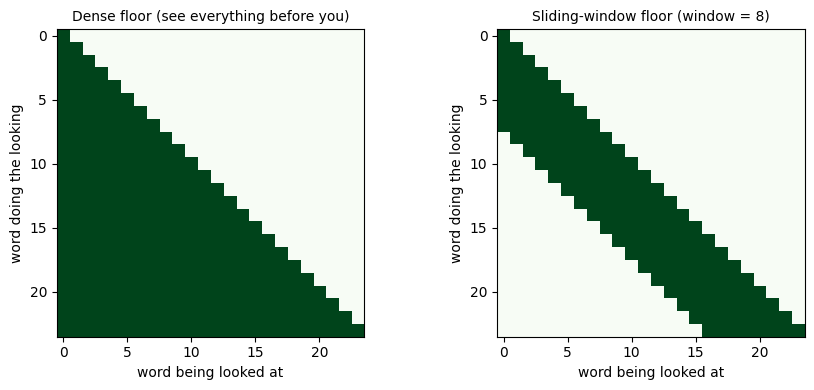

Green = allowed. Row 20 of the right picture may only look at words 13..20.


In [11]:
def build_attention_mask(T: int, sliding_window: int, device) -> torch.Tensor:
    # 0 = allowed to look, -inf = forbidden (softmax turns -inf into 0 %).
    neg_inf = torch.full((T, T), float("-inf"), device=device)
    mask = torch.triu(neg_inf, diagonal=1)                          # no peeking at the future
    if sliding_window > 0:
        mask = mask + torch.tril(neg_inf, diagonal=-sliding_window)  # and no looking too far back
    return mask

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, window, title in zip(axes, [0, 8], ["Dense floor (see everything before you)", "Sliding-window floor (window = 8)"]):
    m = build_attention_mask(24, window, "cpu")
    ax.imshow((m == 0).float(), cmap="Greens", interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("word being looked at")
    ax.set_ylabel("word doing the looking")
plt.tight_layout()
plt.show()
print("Green = allowed. Row 20 of the right picture may only look at words 13..20.")

In [12]:
class Attention(nn.Module):
    def __init__(self, cfg: MiniGPTOSSConfig, layer_idx: int):
        super().__init__()
        self.n_heads = cfg.num_attention_heads
        self.n_kv = cfg.num_key_value_heads
        self.q_mult = self.n_heads // self.n_kv        # queries per shared key/value head
        self.head_dim = cfg.head_dim
        # gpt-oss alternates: even floors use a sliding window, odd floors see everything.
        self.sliding_window = cfg.sliding_window if layer_idx % 2 == 0 else 0

        self.norm = RMSNorm(cfg.hidden_size)
        qkv_width = (self.n_heads + 2 * self.n_kv) * self.head_dim
        self.qkv = nn.Linear(cfg.hidden_size, qkv_width, bias=True)
        self.out = nn.Linear(self.n_heads * self.head_dim, cfg.hidden_size, bias=True)
        self.sinks = nn.Parameter(torch.zeros(self.n_heads))   # one "nobody" slot per head
        self.rope = RotaryEmbedding(self.head_dim, cfg.rope_theta)
        self.sm_scale = 1.0 / math.sqrt(self.head_dim)
        self.record = False           # set True to keep the attention percentages for plotting
        self.last_weights = None

    def forward(self, x):
        B, T, _ = x.shape
        h = self.norm(x)
        qkv = self.qkv(h)
        q, k, v = torch.split(qkv, [self.n_heads * self.head_dim,
                                    self.n_kv * self.head_dim,
                                    self.n_kv * self.head_dim], dim=-1)
        q = q.view(B, T, self.n_heads, self.head_dim)
        k = k.view(B, T, self.n_kv, self.head_dim)
        v = v.view(B, T, self.n_kv, self.head_dim)
        q, k = self.rope(q, k)                                   # stamp positions

        # Group the query heads under their shared key/value head:  (B, kv, q_mult, T, d)
        q = q.view(B, T, self.n_kv, self.q_mult, self.head_dim).permute(0, 2, 3, 1, 4)
        k = k.permute(0, 2, 1, 3)                                # (B, kv, T, d)
        v = v.permute(0, 2, 1, 3)

        scores = torch.einsum("bgmqd,bgkd->bgmqk", q, k) * self.sm_scale
        scores = scores + build_attention_mask(T, self.sliding_window, x.device)

        # Attention sinks: append one extra column per head, softmax, then throw that column away.
        sinks = self.sinks.view(1, self.n_kv, self.q_mult, 1, 1).expand(B, -1, -1, T, 1)
        scores = torch.cat([scores, sinks], dim=-1)
        weights = torch.softmax(scores, dim=-1)[..., :-1]
        if self.record:
            self.last_weights = weights.detach().reshape(B, self.n_heads, T, T)

        mixed = torch.einsum("bgmqk,bgkd->bgmqd", weights, v)
        mixed = mixed.permute(0, 3, 1, 2, 4).reshape(B, T, self.n_heads * self.head_dim)
        return x + self.out(mixed)                               # residual: add to the card

attn_test = Attention(cfg, layer_idx=0)
x_test = torch.randn(2, 10, cfg.hidden_size)     # 2 sentences, 10 tokens each
print("input  :", tuple(x_test.shape))
print("output :", tuple(attn_test(x_test).shape), "(same shape: attention only edits the cards)")
print("sliding window on floor 0:", attn_test.sliding_window, "| on floor 1:", Attention(cfg, 1).sliding_window)

input  : (2, 10, 256)
output : (2, 10, 256) (same shape: attention only edits the cards)
sliding window on floor 0: 32 | on floor 1: 0


## 7. Mixture of Experts: thinking with specialists

After looking around, each word needs to *think* about what it saw. In a classic Transformer that is one big feed-forward network that every word passes through. GPT-OSS replaces it with a **Mixture of Experts (MoE)**:

- There are many small feed-forward networks, the **experts** (32 per floor in gpt-oss-20b, 4 in ours). Think of a hospital floor with 32 specialists.
- A **router** (the receptionist) looks at each word's card and picks the **top-k** most relevant experts (4 in gpt-oss, 2 in ours). Only those experts do any work for that word.
- The chosen experts' answers are blended using the router's confidence scores.

This is why gpt-oss-20b has **21 billion** parameters in total but only **3.6 billion** are used for any given word: most specialists are idle for most words. Big brain, small bill.

Each expert uses **SwiGLU**, a *gated* layer: half its inner numbers decide **what** to say, the other half decide **how much** of it gets through (the gate). GPT-OSS's version clamps the values at ±7 and adds 1 to the gate so that a "closed" gate still lets a little through. We copy the exact formula from the reference implementation.

> **Training note.** If the router is left alone it often learns to send *everything* to one or two favourite experts, and the rest never learn anything. We add a small "fairness" penalty (the load-balancing loss from the Switch Transformer paper) that nudges the router to spread the work. OpenAI has not published the full training recipe for GPT-OSS, so treat this as standard MoE practice rather than a GPT-OSS specific detail.

In [13]:
def swiglu(x, alpha: float = 1.702, limit: float = 7.0):
    # Exactly as in openai/gpt-oss: interleaved [gate, linear] pairs, clamped, gate = x * sigmoid(1.702 x)
    x_glu, x_linear = x[..., ::2], x[..., 1::2]
    x_glu = x_glu.clamp(min=None, max=limit)
    x_linear = x_linear.clamp(min=-limit, max=limit)
    out_glu = x_glu * torch.sigmoid(alpha * x_glu)
    return out_glu * (x_linear + 1)          # the "+1" keeps a trickle flowing through closed gates


class Expert(nn.Module):
    def __init__(self, cfg: MiniGPTOSSConfig):
        super().__init__()
        self.mlp1 = nn.Linear(cfg.hidden_size, 2 * cfg.intermediate_size, bias=True)  # 2x: gate + linear
        self.mlp2 = nn.Linear(cfg.intermediate_size, cfg.hidden_size, bias=True)
        self.limit = cfg.swiglu_limit

    def forward(self, x):
        return self.mlp2(swiglu(self.mlp1(x), limit=self.limit))


class MixtureOfExperts(nn.Module):
    def __init__(self, cfg: MiniGPTOSSConfig):
        super().__init__()
        self.n_experts = cfg.num_experts
        self.k = cfg.experts_per_token
        self.norm = RMSNorm(cfg.hidden_size)
        self.router = nn.Linear(cfg.hidden_size, cfg.num_experts, bias=True)   # the receptionist
        self.experts = nn.ModuleList([Expert(cfg) for _ in range(cfg.num_experts)])
        self.last_counts = None      # how many tokens each expert handled (for plotting)
        self.aux_loss = torch.tensor(0.0)

    def forward(self, x):
        B, T, C = x.shape
        h = self.norm(x).reshape(B * T, C)                     # treat every token independently

        logits = self.router(h)                                # (tokens, experts): how relevant is each expert?
        top_vals, top_idx = logits.topk(self.k, dim=-1)        # pick the k best experts per token
        weights = torch.softmax(top_vals, dim=-1)              # blend weights over the chosen k only (as gpt-oss)

        out = torch.zeros_like(h)
        counts = []
        for e, expert in enumerate(self.experts):
            token_ids, slot = (top_idx == e).nonzero(as_tuple=True)   # which tokens chose expert e?
            counts.append(token_ids.numel())
            if token_ids.numel() == 0:
                continue
            y = expert(h[token_ids]) * weights[token_ids, slot].unsqueeze(-1)
            out.index_add_(0, token_ids, y)                    # send the answers back to their tokens
        self.last_counts = counts

        # Fairness penalty (Switch Transformer): fraction of tokens sent to each expert x mean router prob.
        probs = torch.softmax(logits, dim=-1)
        frac_tokens = F.one_hot(top_idx, self.n_experts).sum(dim=1).float().mean(dim=0) / self.k
        frac_probs = probs.mean(dim=0)
        self.aux_loss = self.n_experts * (frac_tokens * frac_probs).sum()

        return x + out.view(B, T, C)                           # residual: add to the card

moe_test = MixtureOfExperts(cfg)
y_test = moe_test(x_test)
print("input  :", tuple(x_test.shape), " output:", tuple(y_test.shape))
print(f"tokens handled by each of the {cfg.num_experts} experts (20 tokens x top-{cfg.experts_per_token} = 40 assignments):", moe_test.last_counts)
print("fairness penalty (1.0 = perfectly balanced):", round(moe_test.aux_loss.item(), 3))

input  : (2, 10, 256)  output: (2, 10, 256)
tokens handled by each of the 4 experts (20 tokens x top-2 = 40 assignments): [9, 10, 12, 9]
fairness penalty (1.0 = perfectly balanced): 1.001


## 8. One floor, then the whole building

A **Transformer block** is one floor of the building: *look around* (attention) then *think* (experts). Both steps **add** their result to the word's card rather than replacing it, so information from lower floors is never lost. This "residual" trick is what lets us stack many floors.

The full **MiniGPTOSS** is:

1. Embedding table (token → card)
2. `num_hidden_layers` floors
3. Final RMSNorm
4. **Unembedding**: a layer that turns the finished card into a score for every token in the dictionary. The highest score is the model's guess for the next character.

Real gpt-oss-20b stacks 24 floors. We stack 4.

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg: MiniGPTOSSConfig, layer_idx: int):
        super().__init__()
        self.attn = Attention(cfg, layer_idx)
        self.mlp = MixtureOfExperts(cfg)

    def forward(self, x):
        x = self.attn(x)      # look around
        x = self.mlp(x)       # think
        return x


class MiniGPTOSS(nn.Module):
    def __init__(self, cfg: MiniGPTOSSConfig):
        super().__init__()
        self.cfg = cfg
        self.embedding = nn.Embedding(cfg.vocab_size, cfg.hidden_size)
        self.blocks = nn.ModuleList([TransformerBlock(cfg, i) for i in range(cfg.num_hidden_layers)])
        self.norm = RMSNorm(cfg.hidden_size)
        self.unembedding = nn.Linear(cfg.hidden_size, cfg.vocab_size, bias=False)

    def forward(self, token_ids, targets=None, aux_weight: float = 0.01):
        x = self.embedding(token_ids)                 # (B, T, hidden)
        for block in self.blocks:
            x = block(x)
        logits = self.unembedding(self.norm(x))       # (B, T, vocab): a score for every possible next token

        loss = None
        if targets is not None:
            main = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            fairness = torch.stack([b.mlp.aux_loss for b in self.blocks]).mean()
            loss = main + aux_weight * fairness
        return logits, loss

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        expert_params = sum(p.numel() for b in self.blocks for p in b.mlp.experts.parameters())
        active = total - expert_params + expert_params * self.cfg.experts_per_token // self.cfg.num_experts
        return total, active


model = MiniGPTOSS(cfg).to(device)
total, active = model.count_parameters()
print(f"Total parameters : {total:>10,}   (gpt-oss-20b: 21,000,000,000)")
print(f"Active per token : {active:>10,}   (gpt-oss-20b:  3,600,000,000)")
print(f"Ratio active/total: {active / total:.0%}   (gpt-oss-20b: {3.6/21:.0%})")

Total parameters :  3,987,232   (gpt-oss-20b: 21,000,000,000)
Active per token :  2,408,224   (gpt-oss-20b:  3,600,000,000)
Ratio active/total: 60%   (gpt-oss-20b: 17%)


### A newborn model babbles

Before training, every dial is random, so the model's guesses are random. Let's write the generation loop now and watch the nonsense, so the "after" picture later is more satisfying.

**How generation works:** feed the text in, read the scores for the next character, pick one (we sample randomly in proportion to the scores, with a `temperature` knob: lower = safer, higher = wilder), append it, and repeat.

In [15]:
@torch.no_grad()
def generate(model, prompt: str, max_new_tokens: int = 300, temperature: float = 0.8, top_k: int | None = None) -> str:
    model.eval()
    ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        context = ids[:, -model.cfg.block_size:]                 # the model can only see block_size characters
        logits, _ = model(context)
        logits = logits[:, -1, :] / temperature                  # scores for the very next character
        if top_k is not None:
            cutoff = torch.topk(logits, top_k).values[:, -1, None]
            logits = logits.masked_fill(logits < cutoff, float("-inf"))
        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        ids = torch.cat([ids, next_id], dim=1)
    model.train()
    return decode(ids[0].tolist())

print(generate(model, "ROMEO:", max_new_tokens=200))

ROMEO:?M;NOpr?DS3AhyoXSqtHt$'MD?.aSd:HbinC
mZUp$rDMNRMoMyLxJn?$VO!B&RyUbzGAqaFiU.cgAJ'VPBi!:LOPA:GH
$ir.G&.GEmJQ PAqa!X:XMd3tqLv;nin$iqevEAe:VRMYsQg
KPHX&IAc;DX,BKrGAlIkXjHq?MJ kGdNjwWqCVztuWhmXoUTNByuZdTlx


## 9. Training: practising on Shakespeare

Training is a loop of four moves, repeated thousands of times:

1. **Grab a batch** of random snippets from the text (32 snippets of 128 characters each).
2. **Guess** the next character at every position of every snippet.
3. **Grade** the guesses. The grade is the *loss*: how surprised the model was by the true next character. Lower is better. A random guess over 65 characters scores about `ln(65) ≈ 4.2`.
4. **Nudge every dial** a tiny step in the direction that would have made the guess less wrong (back-propagation + the AdamW optimiser).

We hold back 10 % of the text the model never trains on, so we can check it is *learning English* rather than *memorising the book*.

On an Apple-silicon Mac the loop below takes a few minutes. Reduce `MAX_STEPS` if you are in a hurry.

In [16]:
data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]

BATCH_SIZE = 32

def get_batch(split: str):
    src = train_data if split == "train" else val_data
    starts = torch.randint(0, len(src) - cfg.block_size - 1, (BATCH_SIZE,))
    x = torch.stack([src[s : s + cfg.block_size] for s in starts])
    y = torch.stack([src[s + 1 : s + cfg.block_size + 1] for s in starts])   # the same text shifted by one
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("batch of inputs :", tuple(xb.shape))
print("batch of targets:", tuple(yb.shape))
print("example  input  :", repr(decode(xb[0, :40].tolist())))
print("example  target :", repr(decode(yb[0, :40].tolist())), "<- same text, one character later")

batch of inputs : (32, 128)
batch of targets: (32, 128)
example  input  : ' things from Rome; all tending to the go'
example  target : 'things from Rome; all tending to the goo' <- same text, one character later


In [17]:
@torch.no_grad()
def estimate_loss(model, n_batches: int = 20):
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = torch.zeros(n_batches)
        for i in range(n_batches):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[i] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

MAX_STEPS = 2000
EVAL_EVERY = 250
LEARNING_RATE = 1e-3

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_STEPS, eta_min=LEARNING_RATE / 10)

history = {"step": [], "train": [], "val": []}
t0 = time.time()
for step in range(MAX_STEPS + 1):
    if step % EVAL_EVERY == 0:
        losses = estimate_loss(model)
        history["step"].append(step); history["train"].append(losses["train"]); history["val"].append(losses["val"])
        print(f"step {step:>5} | train loss {losses['train']:.3f} | val loss {losses['val']:.3f} | {time.time() - t0:6.0f}s")
    if step == MAX_STEPS:
        break
    x, y = get_batch("train")
    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # keep any one step from being too violent
    optimizer.step()
    scheduler.step()

print(f"Done in {time.time() - t0:.0f} seconds.")

step     0 | train loss 4.423 | val loss 4.436 |      4s
step   250 | train loss 1.617 | val loss 1.795 |    129s
step   500 | train loss 1.446 | val loss 1.633 |    172s
step   750 | train loss 1.348 | val loss 1.601 |    203s
step  1000 | train loss 1.303 | val loss 1.564 |    229s
step  1250 | train loss 1.264 | val loss 1.530 |    255s
step  1500 | train loss 1.224 | val loss 1.513 |    280s
step  1750 | train loss 1.197 | val loss 1.506 |    306s
step  2000 | train loss 1.167 | val loss 1.518 |    332s
Done in 332 seconds.


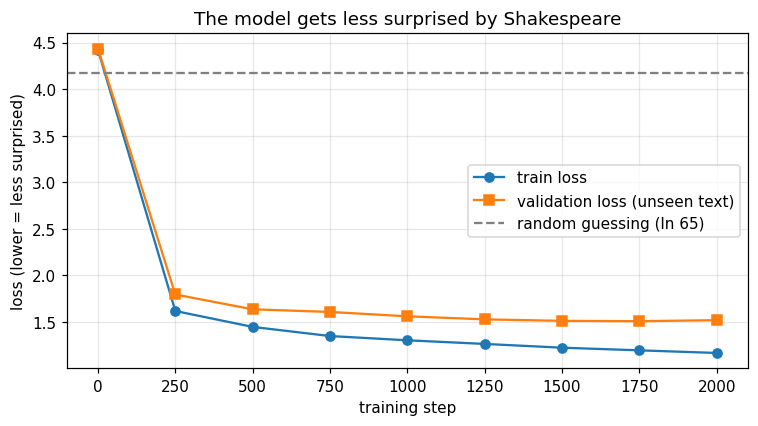

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(history["step"], history["train"], marker="o", label="train loss")
plt.plot(history["step"], history["val"], marker="s", label="validation loss (unseen text)")
plt.axhline(math.log(vocab_size), color="gray", linestyle="--", label=f"random guessing (ln {vocab_size})")
plt.xlabel("training step"); plt.ylabel("loss (lower = less surprised)")
plt.title("The model gets less surprised by Shakespeare")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 10. Generation: the model writes

Same loop as before, but the dials are trained now. The output will not be *good* Shakespeare (we have a 4-million-dial model trained for a few minutes on one book), but it should look like English play-script: character names in capitals, line breaks, mostly real words. Run the cell several times; every run is different because we sample.

In [17]:
print(generate(model, "ROMEO:", max_new_tokens=400, temperature=0.8))

ROMEO:
The riting of calls upon sometime will;
Wherefore his wife and your strong down by the sense
It with you.

AUFIDIUS:
Any hours! for hath contradict me so?

Second Citizen:
We have toucheth me with her shall be hold.

CORIOLANUS:
I am as are to your honesty.

CORIOLANUS:
Here's the pretty poor Thursday be
A worship in this bears of her brother,
To make a trusty carrion trial of the dog,
This ungov


In [18]:
print(generate(model, "First Citizen:\nBefore we proceed any further, hear me speak.", max_new_tokens=300, temperature=0.7, top_k=10))

First Citizen:
Before we proceed any further, hear me speak.

Second Servingman:
The holy foreign of his father down?

Second Citizen:
Well, some tongue, all this son the world burns
I have said a courtesy have and a man
To may not have made him to the torture of our state;
And supply and fear'st more than the heavy foot
Which worthy father hath been a made 


## 11. Looking inside the trained model

Two quick X-rays.

**Which experts get the work?** With the fairness penalty each expert should handle a reasonable share of tokens. Without it you would typically see one bar towering over the others.

**What does attention look at?** For a short prompt we record the attention percentages of one head on the first floor. Bright cells mean "this word (row) paid attention to that word (column)". Because of the causal mask, everything above the diagonal is dark.

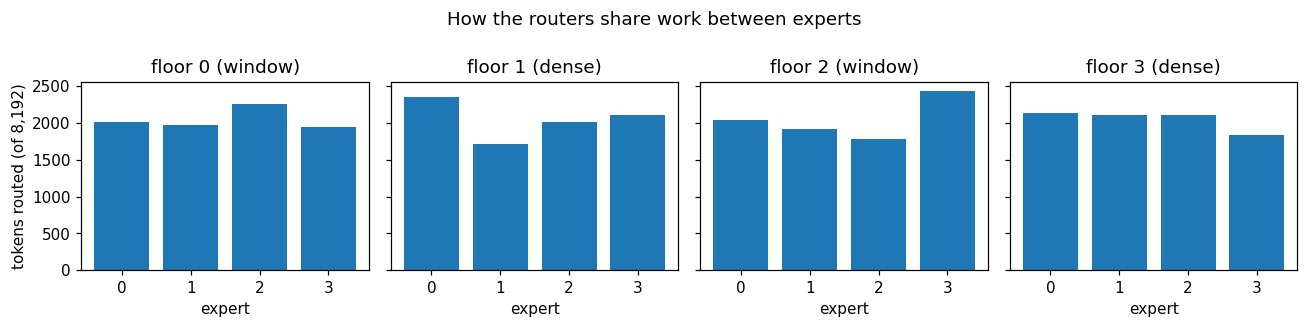

In [19]:
model.eval()
with torch.no_grad():
    x, _ = get_batch("val")
    model(x)

fig, axes = plt.subplots(1, cfg.num_hidden_layers, figsize=(12, 3), sharey=True)
for i, (ax, block) in enumerate(zip(axes, model.blocks)):
    counts = block.mlp.last_counts
    ax.bar(range(cfg.num_experts), counts, color="tab:blue")
    ax.set_title(f"floor {i} ({'window' if block.attn.sliding_window else 'dense'})")
    ax.set_xlabel("expert")
axes[0].set_ylabel(f"tokens routed (of {BATCH_SIZE * cfg.block_size * cfg.experts_per_token:,})")
plt.suptitle("How the routers share work between experts"); plt.tight_layout(); plt.show()

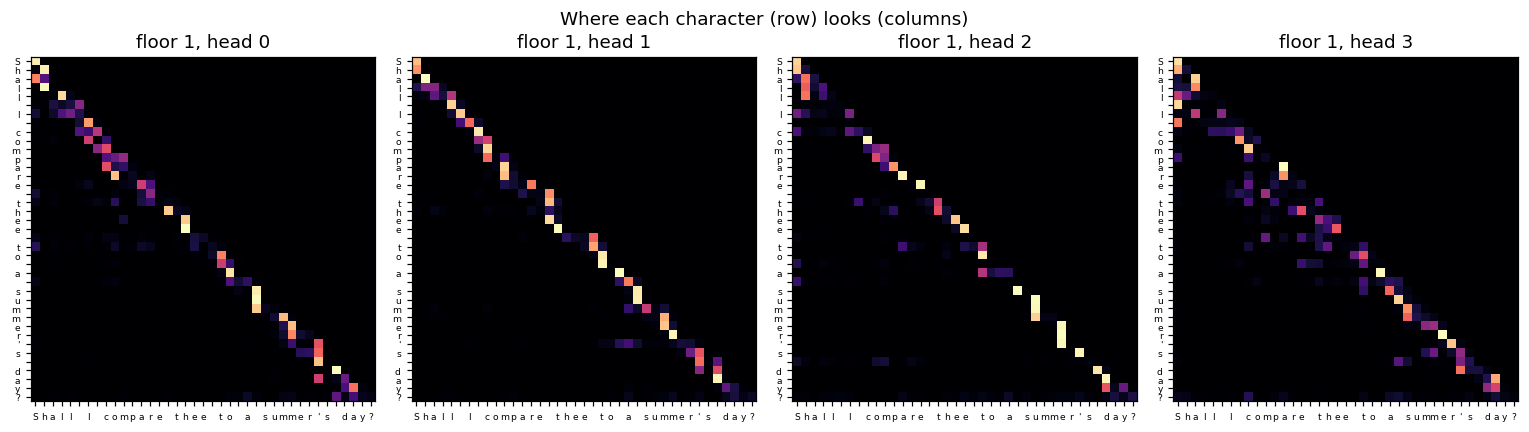

In [20]:
prompt = "Shall I compare thee to a summer's day?"
for block in model.blocks:
    block.attn.record = True
with torch.no_grad():
    model(torch.tensor([encode(prompt)], device=device))
for block in model.blocks:
    block.attn.record = False

weights = model.blocks[1].attn.last_weights[0].cpu()     # floor 1 is a dense floor: (heads, T, T)
fig, axes = plt.subplots(1, cfg.num_attention_heads, figsize=(14, 3.8))
for h, ax in enumerate(axes):
    ax.imshow(weights[h], cmap="magma", interpolation="nearest")
    ax.set_title(f"floor 1, head {h}")
    ax.set_xticks(range(len(prompt))); ax.set_xticklabels(list(prompt), fontsize=6)
    ax.set_yticks(range(len(prompt))); ax.set_yticklabels(list(prompt), fontsize=6)
plt.suptitle("Where each character (row) looks (columns)"); plt.tight_layout(); plt.show()
model.train()

## 12. Save your model, and what we skipped

The checkpoint goes into `data/` (ignored by git). Reload it later with `model.load_state_dict(torch.load(path))`.

In [21]:
CKPT_PATH = os.path.join(DATA_DIR, "mini_gpt_oss.pt")
torch.save({"config": asdict(cfg), "state_dict": model.state_dict(), "chars": chars}, CKPT_PATH)
print(f"Saved {os.path.getsize(CKPT_PATH) / 1e6:.1f} MB to {CKPT_PATH}")

Saved 16.0 MB to data/mini_gpt_oss.pt


### What you built

A working, trainable language model with the GPT-OSS skeleton: RMSNorm → RoPE → grouped-query attention with sinks and alternating sliding windows → a top-k Mixture of Experts with the exact GPT-OSS SwiGLU → stacked blocks → unembedding. Every class maps one-to-one onto a class in `openai/gpt-oss`'s PyTorch reference implementation.

### What separates this from the real gpt-oss-20b

| Topic | Our mini | Real GPT-OSS | Why it matters |
|---|---|---|---|
| Scale | 4 M parameters, 1 MB of text, minutes on a laptop | 21 B parameters, trillions of tokens, thousands of GPUs | Scale is where most of the "intelligence" comes from |
| Tokenizer | 65 characters | 201,088 sub-word pieces (`o200k_harmony`) | Bigger pieces = longer effective memory and faster generation |
| Context length | 128 characters | 131,072 tokens, using RoPE with **YaRN** scaling | Lets the model read whole documents |
| Chat format | none | the **Harmony** format with roles, reasoning channels and tool calls | Turns a next-word guesser into an assistant |
| Post-training | none | distillation from OpenAI's frontier models + reinforcement learning | Teaches reasoning, instruction following and tool use |
| Weights on disk | 32-bit floats | MoE weights stored in **MXFP4** (4-bit) | Makes 120 B parameters fit on one 80 GB GPU |
| Speed tricks | none | KV cache, fused kernels, Triton/Metal backends | Makes generation fast enough to use |

### Where to go next

- **Play:** change `MiniGPTOSSConfig` (more floors, more experts, longer `block_size`) and watch the loss curve and the text quality change.
- **Read the source:** `openai/gpt-oss` → `gpt_oss/torch/model.py`. You will recognise every line.
- **Next notebook in this series:** a KV cache so generation does not re-read the whole prompt for every character, then a sub-word tokenizer, then the Harmony chat format.